In [1]:
import pandas as pd
import plotnine as pn
import numpy as np
from scipy.stats import beta
import itables
from itables import init_notebook_mode
import polars as pl
init_notebook_mode(all_interactive=True)
import itables.options as opt
opt.lengthMenu = [10, 20, 50, 100]
opt.pageLength = 20   # in newer versions; otherwise use show(..., pageLength=20)

from scipy.stats import mannwhitneyu


In [2]:
import sys
sys.path.append("../")   # path to folder containing the python file

from utils.load_gtf_cgc_dresden import *
from utils.util_functions import *
from ProteinExpression.load_pr_data import *


In [3]:
smallest_columns = ["sampleID", "Variant", "germline_promoterAI", "germline_abexp_v1.1", "germline_IMPACT", "five_prime_UTR_variant_consequence", "germline_Consequence", "somatic_snv_promoterAI", "somatic_snv_abexp_v1.1", "somatic_snv_IMPACT", "somatic_snv_Consequence", "HGVSg", "HGVSc", "CharGer_Classification" , "ClinVar_Pathogenicity" , "zScore", "HUGO_Symbol", "Oncotree Code", "Oncotree Text", "IMPACT_snv", "ROLE_IN_CANCER", "CNV", "Tumorzellgehalt (Bioinformatik)"]



res = pd.read_parquet("~/gene_exp_vus.parquet")


# res[(res["CharGer_Classification"] != "Pathogenic")][smallest_columns]

res[smallest_columns]

# ad_vus_outlier[columns]
    

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [ ]:
smallest_columns = ["sampleID", "Variant", "germline_promoterAI", "germline_abexp_v1.1", "germline_IMPACT", "five_prime_UTR_variant_consequence", "germline_Consequence", "somatic_snv_promoterAI", "somatic_snv_abexp_v1.1", "somatic_snv_IMPACT", "somatic_snv_Consequence", "HGVSg", "HGVSc", "CharGer_Classification" , "ClinVar_Pathogenicity" , "zScore", "HUGO_Symbol", "Oncotree Code", "Oncotree Text", "IMPACT_snv", "ROLE_IN_CANCER", "CNV", "Tumorzellgehalt (Bioinformatik)"]



res = pd.read_parquet("~/protein_exp_vus.parquet")


res[(res["CharGer_Classification"] != "Pathogenic")][smallest_columns]


# res[~res['HUGO_Symbol'].isin(extended_dresden_list)][columns]

# ad_vus_outlier[columns]
    

In [3]:
sa = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/sample_data/master_drop_sample_annotation_sizeFactorFiltered_0.1.tsv", sep="\t")


In [4]:
somatic_snvs = pd.read_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/somatic_snvs_vep_annotated.parquet")

# Aberrant Expression

In [5]:
or_res_path = "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/all_cohorts/oht_cov_diag_lr_0_0001_epoc200_gpu/or_variants_interesting_genes_padjust_cnv.parquet"
needed_cols = ["sampleID", "zScore", "pValue", "padjust", "IMPACT", "geneID",  "geneID_short",
               "padjust_predisp", "padjust_predisp_extended", "CNV", "padjust_genes_of_interest"]
py_or_res_all = pl.scan_parquet(or_res_path).select(needed_cols).filter((pl.col("padjust_genes_of_interest") <= 0.1)).collect().to_pandas()
py_or_res_all["Method"] = "OUTRIDER"

# py_or_res_all = py_or_res_all[(py_or_res_all["padjust_predisp_extended"] <= 0.05) | (py_or_res_all["padjust"] <= 0.05)]


py_or_res_all = pd.merge(py_or_res_all, sa[["pid", "Diag", "seq_type", "Oncotree Code", "Oncotree Text", "nct_pid", "Tumorzellgehalt (Bioinformatik)"]], left_on="sampleID", right_on="pid")
py_or_res_all = pd.merge(py_or_res_all, cgc[[ "ROLE_IN_CANCER", "geneID"]], on="geneID", how="left")

py_or_res_all = py_or_res_all.sort_values("pValue")
py_or_res_aberrant = py_or_res_all.drop_duplicates(subset=["sampleID", "geneID_short"])

# py_or_res_aberrant["key"] = py_or_res_aberrant["sampleID"] +  "." + py_or_res_aberrant["nct_pid"].str.split("_").str[1]
py_or_res_aberrant = py_or_res_aberrant[(py_or_res_aberrant["padjust_predisp_extended"].notna()) | (py_or_res_aberrant["geneID_short"].isin(cgc["geneID_short"]))]
sample_ids = py_or_res_aberrant["sampleID"].unique()
py_or_res_aberrant = py_or_res_aberrant.merge(somatic_snvs[["somatic_snv_#Uploaded_variation", "sampleID", "MASTER_annotated_gene", "vep_Gene", "somatic_snv_IMPACT", "somatic_snv_Consequence", "somatic_snv_max_spliceai_score", "somatic_snv_am_pathogenicity", "somatic_snv_AbSplice2_max", "somatic_snv_promoterAI", "somatic_snv_abexp_v1.1"]] , left_on=["geneID_short", "sampleID"], right_on=["vep_Gene", "sampleID"], how="left")


# Protein expression

In [6]:
pr_output_name = "cov_gaussian_gs_lr_0_001_epoc2000_noInitPCA"

pr_res_all = pl.scan_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/output_" + pr_output_name + "/pr_variants_interesting_genes_padjust_cnv.parquet").filter((pl.col("padjust_genes_of_interest") <= 0.1)).collect(engine="streaming").to_pandas()
pr_res_all = pd.merge(pr_res_all, dresden_dt_cgc[["gene_name", "gene_type", "geneID_short", "ROLE_IN_CANCER", "predisposition_gene"]], right_on="geneID_short", left_on="geneID", how="left")
pr_res_all = pd.merge(pr_res_all, sa, left_on="sampleID", right_on="pid")
pr_res_aberrant = pr_res_all.merge(somatic_snvs[["somatic_snv_#Uploaded_variation", "sampleID", "MASTER_annotated_gene", "vep_Gene", "somatic_snv_IMPACT", "somatic_snv_Consequence", "somatic_snv_max_spliceai_score", "somatic_snv_am_pathogenicity", "somatic_snv_AbSplice2_max", "somatic_snv_promoterAI", "somatic_snv_abexp_v1.1"]] , left_on=["geneID", "sampleID"], right_on=["vep_Gene", "sampleID"], how="left")

pr_samples = pr_res_aberrant["sampleID"].unique()

# Variants

In [28]:
gene_annot_pl = pl.from_pandas(gene_annot_dt[["gene_name", "geneID_short"]])

germline_snvs = (
    pl.scan_parquet(
        "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/germline_predisp_cgc_all_TINDA.parquet"
    )
    # Apply all filters first to reduce data size
    .filter(
        (pl.col("sampleID").is_in(sample_ids))
        | (pl.col("sampleID").is_in(pr_samples))
    )
    # Perform the join within Polars using join_as_coerced
    .join(
        gene_annot_pl.lazy(), left_on="HUGO_Symbol", right_on="gene_name", how="inner"
    )
    # .filter(pl.col("geneID_short").is_in(genes_of_interest["geneID_short"]))
    .filter(pl.col("geneID_short").is_in(AD_inheritence["geneID_short"]))
    # Collect using the streaming engine and convert to Pandas
    .collect(engine="streaming")
    .to_pandas()
)


germline_snvs = germline_snvs.rename(columns={"#CHROM": "seqnames", "REF": "Ref", "ALT": "Alt"})
print(germline_snvs.shape)

germline_snvs["chrom"] = "chr" + germline_snvs["seqnames"]
germline_snvs.shape

valid_positions = (
    germline_snvs["POS"]
    .dropna()
    .unique()
    .astype(int)
    .tolist()
)

germline_snvs[["VEP_Ref", "VEP_Alt"]] = germline_snvs.apply(
    to_vep_alleles, axis=1
)


germline_snvs["Location"] = germline_snvs.apply(
    lambda row: compute_vep_location(
        {
            "#CHROM": row["seqnames"],
            "POS": row["POS"],
            "REF": row["VEP_Ref"],
            "ALT": row["VEP_Alt"],
        }
    ),
    axis=1,
)


germline_snvs[["VEP_Ref", "VEP_Alt"]] = germline_snvs.apply(vep_normalize_row, axis=1)


(260362, 63)


NameError: name 'df' is not defined

In [29]:
germline_snvs[["VEP_Ref", "VEP_Alt"]] = germline_snvs.apply(vep_normalize_row, axis=1)


# Plot VUS number

/tmp/ipykernel_883518/184584967.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



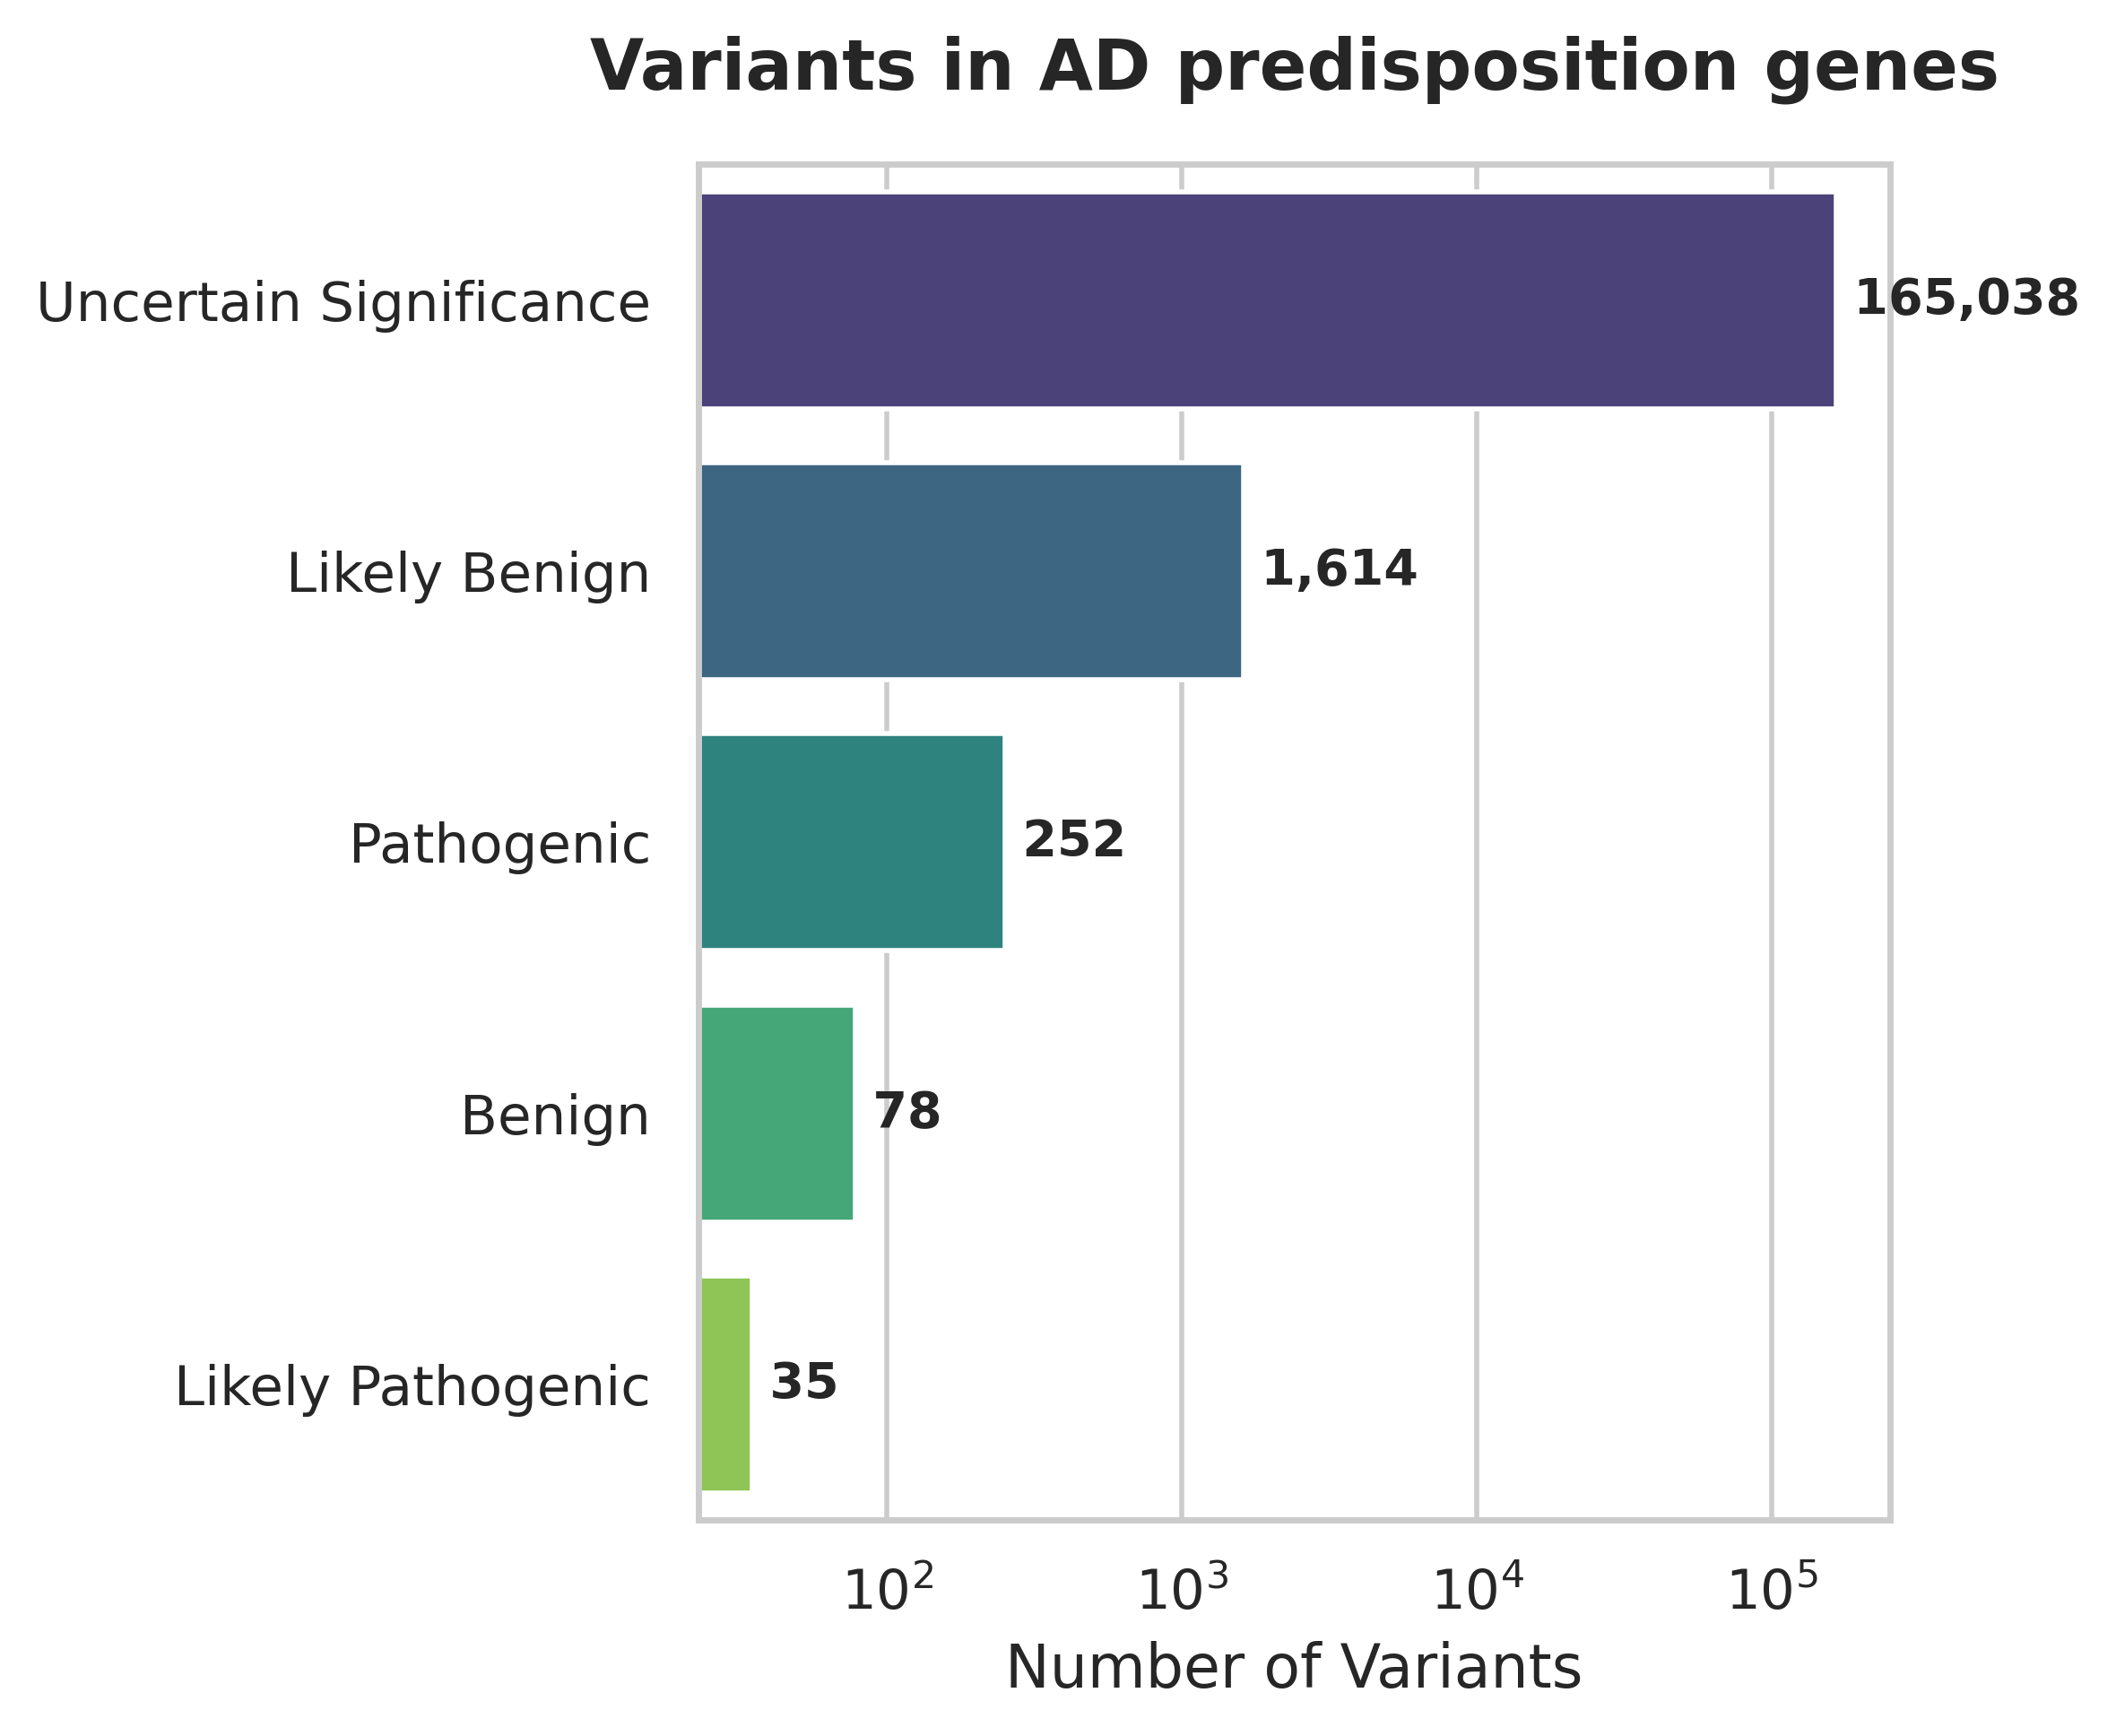

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd



data = pd.DataFrame(germline_snvs[germline_snvs["HUGO_Symbol"].isin(AD_inheritence["Approved symbol (HGNC)"])]["CharGer_Classification"].value_counts())

data["Significance"] = data.index
df = data.sort_values(by='count', ascending=False) # Sort largest to smallest

# 2. Plotting
plt.figure(figsize=(6, 5), dpi=400)
sns.set_theme(style="whitegrid")

# Create horizontal bar plot with a log scale
ax = sns.barplot(x='count', y='Significance', data=df, palette="viridis")
ax.set_xscale('log')

# Add titles and clean up axes
plt.title("Variants in AD predisposition genes", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Number of Variants", fontsize=12)
plt.ylabel("")

# 3. Add the exact numbers as text labels next to the bars
for index, row in df.iterrows():
    ax.text(row['count'], df.index.get_loc(index), f" {int(row['count']):,}", 
            va='center', ha='left', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# back to code

In [30]:
germline_vep_res = pl.scan_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/cnv/germline_predisp_cgc_all_TINDA_vep.parquet",).collect(engine="streaming").to_pandas()


germline_vep_res["chrom"] = germline_vep_res["Location"].str.split(":").str[0]
germline_vep_res["POS"] = 0
germline_vep_res.loc[germline_vep_res["VARIANT_CLASS"] == "SNV", "POS"] = germline_vep_res.loc[germline_vep_res["VARIANT_CLASS"] == "SNV", "Location"].str.split(":").str[1].astype(int)
# germline_vep_res["POS"] = germline_vep_res["POS"] + 1
germline_snvs = germline_snvs.merge(germline_vep_res[["chrom", "POS", "Location", "VARIANT_CLASS", "Allele", "REF_ALLELE", "IMPACT", "Consequence", "Gene", "#Uploaded_variation", "am_pathogenicity", "am_class", "LoF", "CADD_PHRED", "CADD_RAW","existing_InFrame_oORFs",  "existing_OutOfFrame_oORFs","existing_uORFs", "five_prime_UTR_variant_annotation", "five_prime_UTR_variant_consequence", "max_spliceai_score"]], left_on=["Location", "VEP_Ref", "VEP_Alt", "geneID_short"], right_on=["Location", "REF_ALLELE", "Allele", "Gene"], how="left") 

germline_snvs.shape

(300933, 87)

In [31]:
germline_snvs[germline_snvs["Alt"].str.len() > 1]["IMPACT"].value_counts()

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [9]:
germline_snvs[germline_snvs["Alt"].str.len() > 1]["IMPACT"].value_counts()

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [32]:
germline_snvs[(germline_snvs["Alt"].str.len() > 1)  ]["IMPACT"].value_counts()
germline_snvs[(germline_snvs["Alt"].str.len() > 1) & (germline_snvs["am_pathogenicity"].isna())][["Alt", "Ref", "seqnames", "POS_x", "Location", "Consequence", "am_pathogenicity", "VEP_Alt", "VEP_Ref", "geneID_short"]]



Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [26]:


# Test your exact case
ref_seq = "ACACTCTCT"
alt_seq = "TCT"

print(vep_normalize(ref_seq, alt_seq))

ACACTC/-


In [25]:
germline_vep_res[(germline_vep_res["Location"] == "3:10195982")]
germline_vep_res[germline_vep_res["Location"] == "21:36419858-36419866"]
germline_vep_res[(germline_vep_res["REF_ALLELE"] == "TCT")]


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


# PromoterAI and AbExp

In [11]:
abexp = pl.scan_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/resources/predisp_cgc_max_abexp.parquet").filter((pl.col("start").is_in(valid_positions)) | (pl.col("end").is_in(valid_positions))).collect(engine="streaming").to_pandas()

abexp["seqnames"] = abexp["chrom"].str.split("chr").str[1]



In [12]:
promoter_ai = (pl.scan_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/resources/promoterAI_tss500_hg19.parquet")
                .filter((pl.col("gene_id").is_in(genes_of_interest["geneID_short"])))
                .filter(pl.col("hg19_start").is_in(valid_positions))
                .collect(engine="streaming").to_pandas()
              )
df_sorted = promoter_ai.sort_values(
    by="promoterAI",
    key=lambda x: x.abs(),
    ascending=False
)
promoter_ai = df_sorted.drop_duplicates(
    subset=["chrom", "pos", "ref", "alt", "gene_id", "strand"],
    keep="first"
)
promoter_ai["chrom"] = promoter_ai["chrom"].str[3:]



In [13]:
merged_vars = germline_snvs.merge(promoter_ai, left_on=["seqnames", "POS_x", "Ref", "Alt", "geneID_short"], right_on=["chrom", "hg19_start", "ref", "alt", "gene_id"], how="left").drop(columns=["chrom_x", "chrom"])      

merged_vars = merged_vars.merge(abexp, left_on=["POS_x", "seqnames", "Ref", "Alt", "geneID_short"], right_on=["end", "seqnames", "ref", "alt", "gene"], how="left")

merged_vars = merged_vars.rename(columns={"#Uploaded_variation": "germline_#Uploaded_variation", "Consequence": "germline_Consequence", "IMPACT": "germline_IMPACT", "am_pathogenicity": "germline_am_pathogenicity","LoF": "germline_am_LoF", "max_spliceai_score": "germilne_max_spliceai_score", "pangolin_score": "germline_pangolin_score", "AbSplice2_max": "germline_AbSplice2_max", "promoterAI": "germline_promoterAI", "abexp_v1.1": "germline_abexp_v1.1" })


merged_vars["Variant"] = (
    merged_vars["seqnames"] + ":" + 
    merged_vars["POS_x"].astype(str) + ":" + 
    merged_vars["Ref"] + ":" + 
    merged_vars["Alt"]
)

merged_vars.loc[merged_vars["germline_am_pathogenicity"] ==  "-", "germline_am_pathogenicity"] = "0"
merged_vars["germline_am_pathogenicity"] = pd.to_numeric(
    merged_vars["germline_am_pathogenicity"], errors="coerce"
)

In [14]:
predisp_absplice = merged_vars.merge(py_or_res_aberrant, right_on=["sampleID", "geneID_short"], left_on=["sampleID", "gene_id"], how="left")
# predisp_absplice = predisp_absplice.drop_duplicates(subset=["pid", "start", "end", "Ref", "Alt"])

predisp_absplice["Outlier status"] = False
predisp_absplice.loc[predisp_absplice["geneID_short_y"].notna(), "Outlier status"] = True

In [15]:

predisp_absplice[(predisp_absplice["Alt"].str.len() > 1) & (predisp_absplice["Outlier status"] == True)]["germline_IMPACT"].value_counts()

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [63]:
predisp_absplice[(predisp_absplice["Alt"].str.len() > 1)].head()

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


## plots

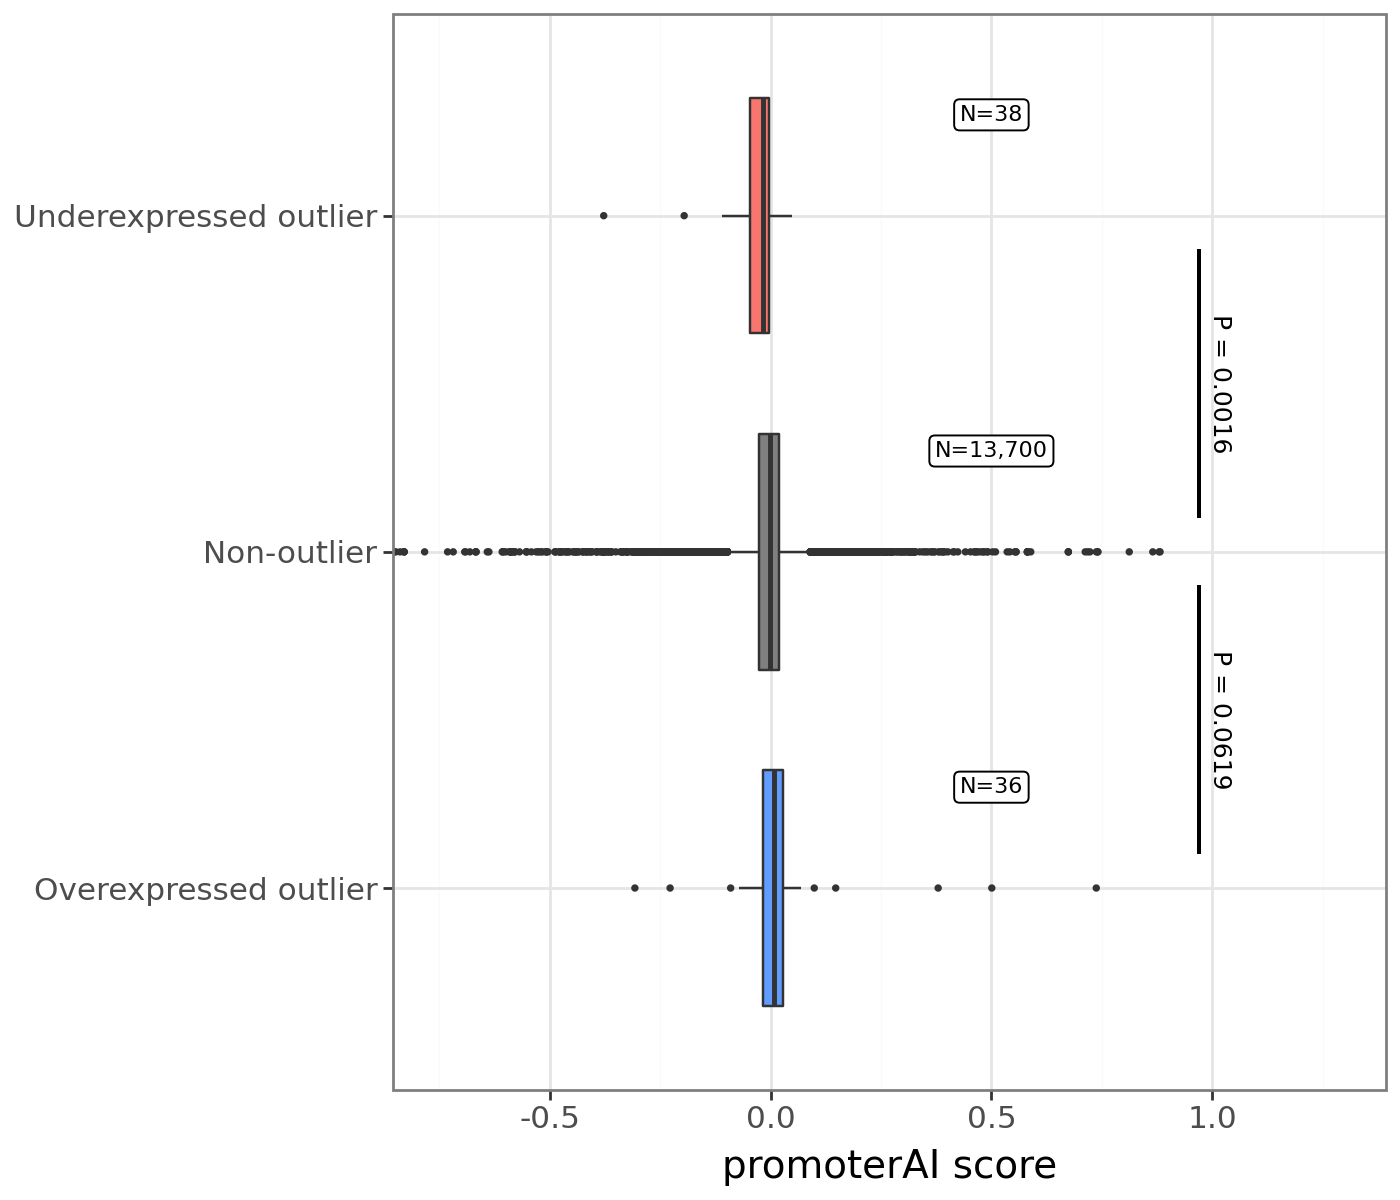

In [12]:
import pandas as pd
import numpy as np
import plotnine as pn
from scipy.stats import mannwhitneyu

# 1. Categorization
df_plot = predisp_absplice.copy()
conditions = [
    (df_plot['Outlier status'] == True) & (df_plot['zScore'] < 0),
    (df_plot['Outlier status'] == False),
    (df_plot['Outlier status'] == True) & (df_plot['zScore'] > 0)
]

choices = ['Underexpressed outlier', 'Non-outlier', 'Overexpressed outlier']
df_plot['plot_group'] = np.select(conditions, choices, default='Non-outlier')

# Order: Over (Bottom/1), Non (Mid/2), Under (Top/3)
group_order = ['Overexpressed outlier', 'Non-outlier', 'Underexpressed outlier']
df_plot['plot_group'] = pd.Categorical(df_plot['plot_group'], categories=group_order, ordered=True)

# 2. Extract series for stats
under_vals = df_plot[df_plot['plot_group'] == 'Underexpressed outlier']["promoterAI"]
none_vals = df_plot[df_plot['plot_group'] == 'Non-outlier']["promoterAI"]
over_vals = df_plot[df_plot['plot_group'] == 'Overexpressed outlier']["promoterAI"]

# 3. Stats
p_under = mannwhitneyu(under_vals, none_vals, alternative='less').pvalue if len(under_vals) > 0 else np.nan
p_over = mannwhitneyu(over_vals, none_vals, alternative='greater').pvalue if len(over_vals) > 0 else np.nan

def format_p(p):
    return f"P = {p:.1e}" if p < 0.001 else f"P = {p:.4f}"

# 4. Plot
# We define bracket positions. y_pos is the horizontal line location.
y_max = df_plot["promoterAI"].max()
bracket_y = y_max * 1.1  # Position brackets slightly outside the data range

p = (
    pn.ggplot(df_plot, pn.aes(x="plot_group", y="promoterAI", fill="plot_group"))
    + pn.geom_boxplot(outlier_size=0.5, width=0.7)
    + pn.coord_flip()
    + pn.scale_fill_manual(values={"Underexpressed outlier": "#f8766d", "Non-outlier": "#7f7f7f", "Overexpressed outlier": "#619cff"}, guide=None)
    + pn.theme_bw(base_size=14)
    + pn.theme(figure_size=(7, 6), axis_title_y=pn.element_blank())
    + pn.labs(y="promoterAI score")
    
    # --- Brackets & P-values ---
    # Bracket for Underexpressed (x=3) vs Non-outlier (x=2)
    + pn.geom_segment(pn.aes(x=2.1, xend=2.9, y=bracket_y, yend=bracket_y)) # Vertical bar (flipped)
    + pn.annotate("text", x=2.5, y=bracket_y * 1.05, label=format_p(p_under), size=9, angle=270)
    
    # Bracket for Overexpressed (x=1) vs Non-outlier (x=2)
    + pn.geom_segment(pn.aes(x=1.1, xend=1.9, y=bracket_y, yend=bracket_y)) # Vertical bar (flipped)
    + pn.annotate("text", x=1.5, y=bracket_y * 1.05, label=format_p(p_over), size=9, angle=270)
    
    # --- N Labels ---
    + pn.annotate("label", x=3.3, y=0.5, label=f"N={len(under_vals):,}", fill="white", size=8)
    + pn.annotate("label", x=2.3, y=0.5, label=f"N={len(none_vals):,}", fill="white", size=8)
    + pn.annotate("label", x=1.3, y=0.5, label=f"N={len(over_vals):,}", fill="white", size=8)
    
    # Expand the plot to make room for brackets
    + pn.scale_y_continuous(expand=(0, 0, 0.2, 0)) 
)

p

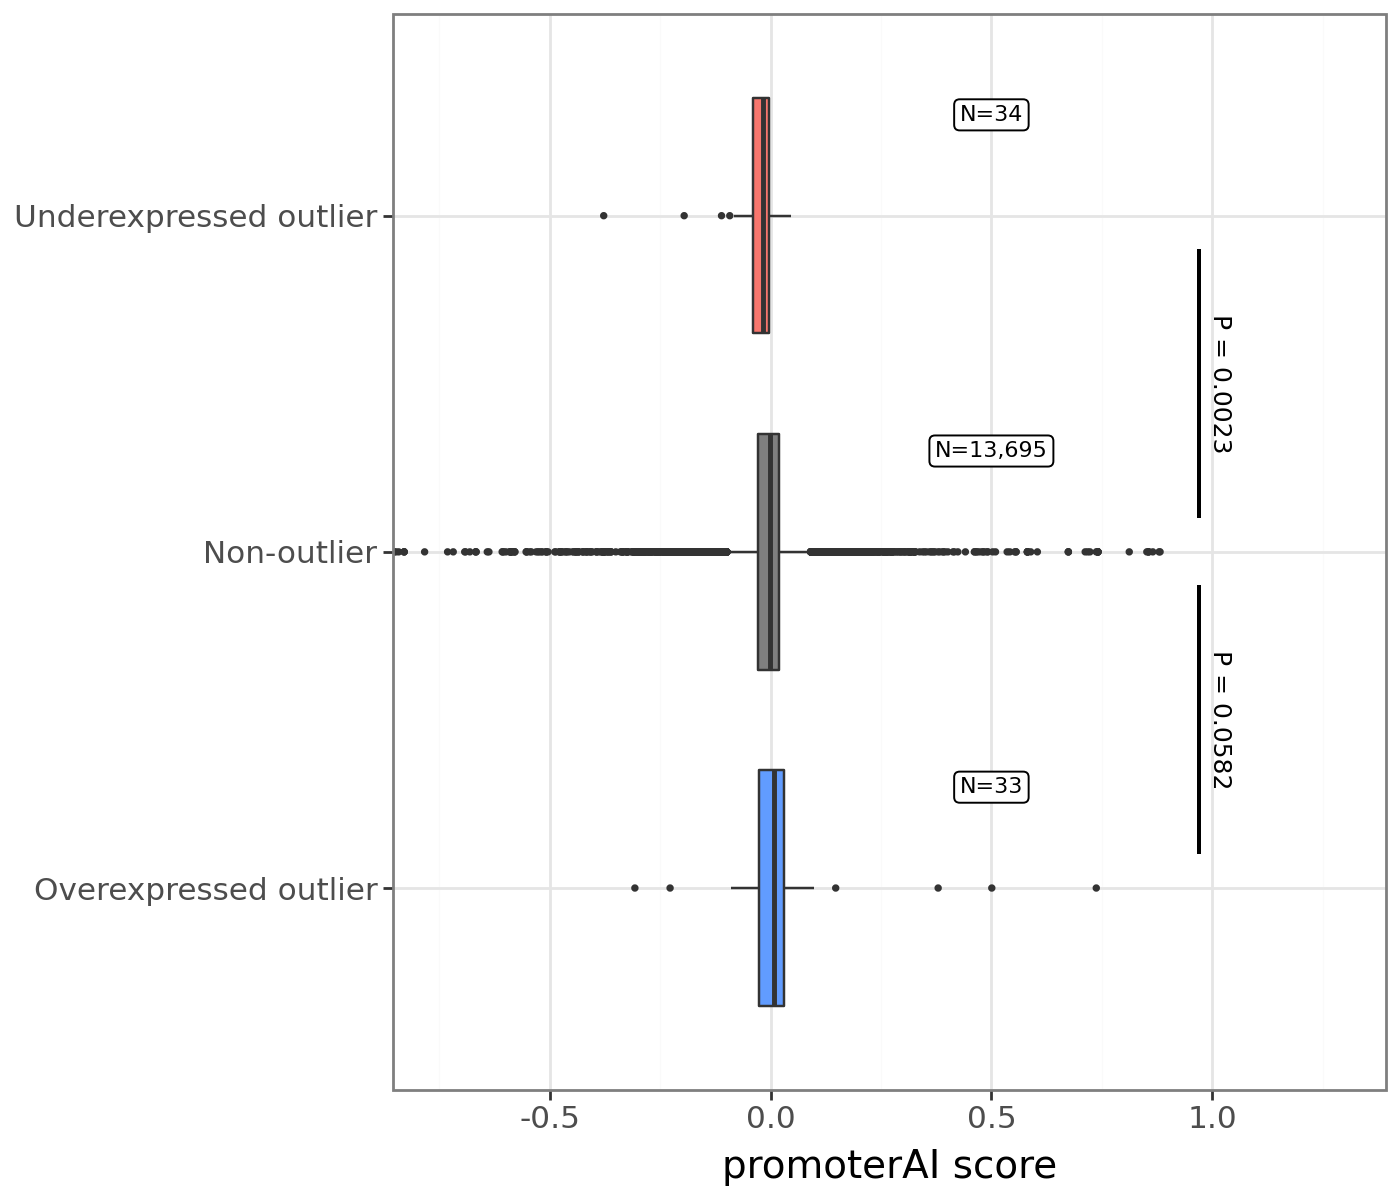

In [34]:
import pandas as pd
import numpy as np
import plotnine as pn
from scipy.stats import mannwhitneyu

# 1. Categorization
df_plot = predisp_absplice[(predisp_absplice["Tumorzellgehalt (Bioinformatik)"] >= 0.2) | (predisp_absplice["Tumorzellgehalt (Bioinformatik)"].isna()) ].copy()
conditions = [
    (df_plot['Outlier status'] == True) & (df_plot['zScore'] < 0),
    (df_plot['Outlier status'] == False),
    (df_plot['Outlier status'] == True) & (df_plot['zScore'] > 0)
]

choices = ['Underexpressed outlier', 'Non-outlier', 'Overexpressed outlier']
df_plot['plot_group'] = np.select(conditions, choices, default='Non-outlier')

# Order: Over (Bottom/1), Non (Mid/2), Under (Top/3)
group_order = ['Overexpressed outlier', 'Non-outlier', 'Underexpressed outlier']
df_plot['plot_group'] = pd.Categorical(df_plot['plot_group'], categories=group_order, ordered=True)

# 2. Extract series for stats
under_vals = df_plot[df_plot['plot_group'] == 'Underexpressed outlier']["promoterAI"]
none_vals = df_plot[df_plot['plot_group'] == 'Non-outlier']["promoterAI"]
over_vals = df_plot[df_plot['plot_group'] == 'Overexpressed outlier']["promoterAI"]

# 3. Stats
p_under = mannwhitneyu(under_vals, none_vals, alternative='less').pvalue if len(under_vals) > 0 else np.nan
p_over = mannwhitneyu(over_vals, none_vals, alternative='greater').pvalue if len(over_vals) > 0 else np.nan

def format_p(p):
    return f"P = {p:.1e}" if p < 0.001 else f"P = {p:.4f}"

# 4. Plot
# We define bracket positions. y_pos is the horizontal line location.
y_max = df_plot["promoterAI"].max()
bracket_y = y_max * 1.1  # Position brackets slightly outside the data range

p = (
    pn.ggplot(df_plot, pn.aes(x="plot_group", y="promoterAI", fill="plot_group"))
    + pn.geom_boxplot(outlier_size=0.5, width=0.7)
    + pn.coord_flip()
    + pn.scale_fill_manual(values={"Underexpressed outlier": "#f8766d", "Non-outlier": "#7f7f7f", "Overexpressed outlier": "#619cff"}, guide=None)
    + pn.theme_bw(base_size=14)
    + pn.theme(figure_size=(7, 6), axis_title_y=pn.element_blank())
    + pn.labs(y="promoterAI score")
    
    # --- Brackets & P-values ---
    # Bracket for Underexpressed (x=3) vs Non-outlier (x=2)
    + pn.geom_segment(pn.aes(x=2.1, xend=2.9, y=bracket_y, yend=bracket_y)) # Vertical bar (flipped)
    + pn.annotate("text", x=2.5, y=bracket_y * 1.05, label=format_p(p_under), size=9, angle=270)
    
    # Bracket for Overexpressed (x=1) vs Non-outlier (x=2)
    + pn.geom_segment(pn.aes(x=1.1, xend=1.9, y=bracket_y, yend=bracket_y)) # Vertical bar (flipped)
    + pn.annotate("text", x=1.5, y=bracket_y * 1.05, label=format_p(p_over), size=9, angle=270)
    
    # --- N Labels ---
    + pn.annotate("label", x=3.3, y=0.5, label=f"N={len(under_vals):,}", fill="white", size=8)
    + pn.annotate("label", x=2.3, y=0.5, label=f"N={len(none_vals):,}", fill="white", size=8)
    + pn.annotate("label", x=1.3, y=0.5, label=f"N={len(over_vals):,}", fill="white", size=8)
    
    # Expand the plot to make room for brackets
    + pn.scale_y_continuous(expand=(0, 0, 0.2, 0)) 
)

p

In [ ]:
import pandas as pd
import numpy as np
import plotnine as pn
from scipy.stats import mannwhitneyu

# 1. Categorization
df_plot = predisp_absplice.copy()
conditions = [
    (df_plot['Outlier status'] == True) & (df_plot['zScore'] < 0),
    (df_plot['Outlier status'] == False),
    (df_plot['Outlier status'] == True) & (df_plot['zScore'] > 0)
]

choices = ['Underexpressed outlier', 'Non-outlier', 'Overexpressed outlier']
df_plot['plot_group'] = np.select(conditions, choices, default='Non-outlier')

# Order: Over (Bottom/1), Non (Mid/2), Under (Top/3)
group_order = ['Overexpressed outlier', 'Non-outlier', 'Underexpressed outlier']
df_plot['plot_group'] = pd.Categorical(df_plot['plot_group'], categories=group_order, ordered=True)

# 2. Extract series for stats
under_vals = df_plot[df_plot['plot_group'] == 'Underexpressed outlier']["promoterAI"]
none_vals = df_plot[df_plot['plot_group'] == 'Non-outlier']["promoterAI"]
over_vals = df_plot[df_plot['plot_group'] == 'Overexpressed outlier']["promoterAI"]

# 3. Stats
p_under = mannwhitneyu(under_vals, none_vals, alternative='less').pvalue if len(under_vals) > 0 else np.nan
p_over = mannwhitneyu(over_vals, none_vals, alternative='greater').pvalue if len(over_vals) > 0 else np.nan

def format_p(p):
    return f"P = {p:.1e}" if p < 0.001 else f"P = {p:.4f}"

# 4. Plot
# We define bracket positions. y_pos is the horizontal line location.
y_max = df_plot["promoterAI"].max()
bracket_y = y_max * 1.1  # Position brackets slightly outside the data range

p = (
    pn.ggplot(df_plot, pn.aes(x="plot_group", y="promoterAI", fill="plot_group"))
    + pn.geom_boxplot(outlier_size=0.5, width=0.7)
    + pn.coord_flip()
    + pn.scale_fill_manual(values={"Underexpressed outlier": "#f8766d", "Non-outlier": "#7f7f7f", "Overexpressed outlier": "#619cff"}, guide=None)
    + pn.theme_bw(base_size=14)
    + pn.theme(figure_size=(7, 6), axis_title_y=pn.element_blank())
    + pn.labs(y="promoterAI score")
    
    # --- Brackets & P-values ---
    # Bracket for Underexpressed (x=3) vs Non-outlier (x=2)
    + pn.geom_segment(pn.aes(x=2.1, xend=2.9, y=bracket_y, yend=bracket_y)) # Vertical bar (flipped)
    + pn.annotate("text", x=2.5, y=bracket_y * 1.05, label=format_p(p_under), size=9, angle=270)
    
    # Bracket for Overexpressed (x=1) vs Non-outlier (x=2)
    + pn.geom_segment(pn.aes(x=1.1, xend=1.9, y=bracket_y, yend=bracket_y)) # Vertical bar (flipped)
    + pn.annotate("text", x=1.5, y=bracket_y * 1.05, label=format_p(p_over), size=9, angle=270)
    
    # --- N Labels ---
    + pn.annotate("label", x=3.3, y=0.5, label=f"N={len(under_vals):,}", fill="white", size=8)
    + pn.annotate("label", x=2.3, y=0.5, label=f"N={len(none_vals):,}", fill="white", size=8)
    + pn.annotate("label", x=1.3, y=0.5, label=f"N={len(over_vals):,}", fill="white", size=8)
    
    # Expand the plot to make room for brackets
    + pn.scale_y_continuous(expand=(0, 0, 0.2, 0)) 
)

p

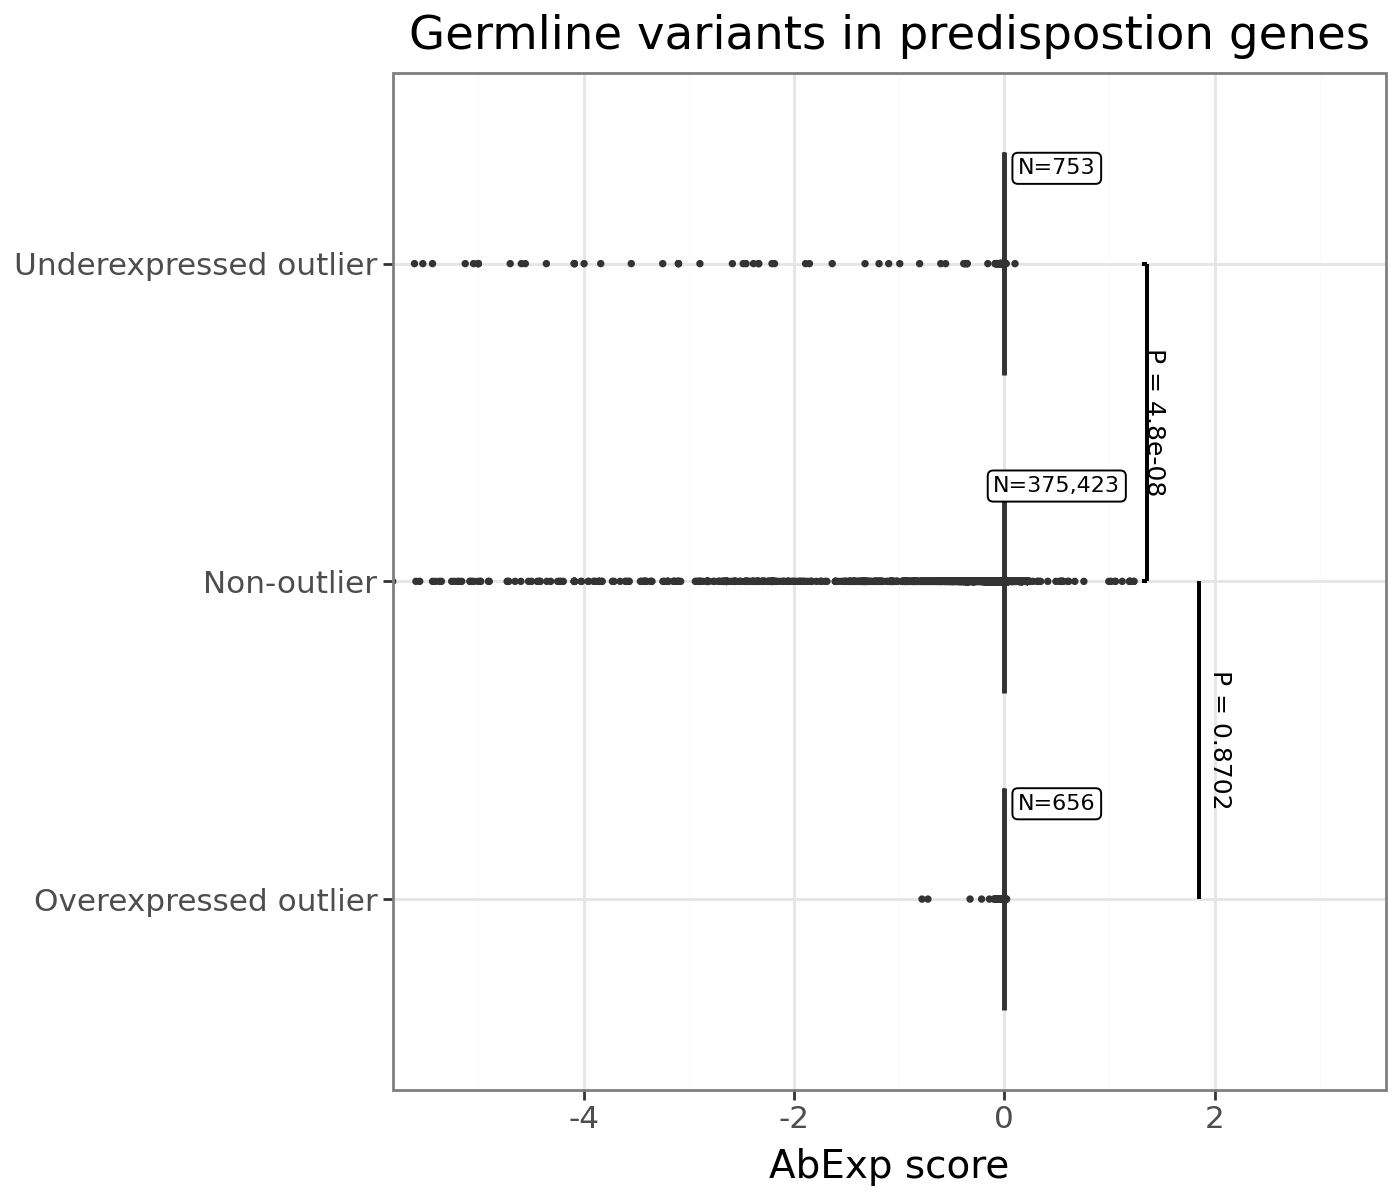

In [35]:
import pandas as pd
import numpy as np
import plotnine as pn
from scipy.stats import mannwhitneyu

tip_size = 0.05

# 1. Categorization
df_plot = predisp_snvs.copy()
conditions = [
    (df_plot['Outlier status'] == True) & (df_plot['zScore'] < 0),
    (df_plot['Outlier status'] == False),
    (df_plot['Outlier status'] == True) & (df_plot['zScore'] > 0)
]
choices = ['Underexpressed outlier', 'Non-outlier', 'Overexpressed outlier']
df_plot['plot_group'] = np.select(conditions, choices, default='Non-outlier')

# Order: Over (Bottom/1), Non (Mid/2), Under (Top/3)
group_order = ['Overexpressed outlier', 'Non-outlier', 'Underexpressed outlier']
df_plot['plot_group'] = pd.Categorical(df_plot['plot_group'], categories=group_order, ordered=True)

# 2. Extract series for stats
under_vals = df_plot[df_plot['plot_group'] == 'Underexpressed outlier']["abexp_v1.1"]
none_vals = df_plot[df_plot['plot_group'] == 'Non-outlier']["abexp_v1.1"]
over_vals = df_plot[df_plot['plot_group'] == 'Overexpressed outlier']["abexp_v1.1"]

# 3. Stats
p_under = mannwhitneyu(under_vals, none_vals, alternative='less').pvalue if len(under_vals) > 0 else np.nan
p_over = mannwhitneyu(over_vals, none_vals, alternative='greater').pvalue if len(over_vals) > 0 else np.nan

def format_p(p):
    return f"P = {p:.1e}" if p < 0.001 else f"P = {p:.4f}"

# 4. Plot
# We define bracket positions. y_pos is the horizontal line location.
y_max = df_plot["abexp_v1.1"].max()
bracket_y = y_max * 1.1  # Position brackets slightly outside the data range

p = (
    pn.ggplot(df_plot, pn.aes(x="plot_group", y="abexp_v1.1", fill="plot_group"))
    + pn.geom_boxplot(outlier_size=0.5, width=0.7)
    + pn.coord_flip()
    + pn.scale_fill_manual(values={"Underexpressed outlier": "#f8766d", "Non-outlier": "#7f7f7f", "Overexpressed outlier": "#619cff"}, guide=None)
    + pn.theme_bw(base_size=14)
    + pn.theme(figure_size=(7, 6), axis_title_y=pn.element_blank())
    + pn.labs(y="AbExp score", title="Germline variants in predispostion genes")
    
    # --- Brackets & P-values ---
    # Bracket for Underexpressed (x=3) vs Non-outlier (x=2)
    + pn.geom_segment(pn.aes(x=2, xend=3, y=bracket_y, yend=bracket_y)) # Vertical bar (flipped)
    + pn.geom_segment(pn.aes(x=2, xend=2, y=bracket_y, yend=bracket_y - tip_size)) # Bottom tip
    + pn.geom_segment(pn.aes(x=3, xend=3, y=bracket_y, yend=bracket_y - tip_size)) # Top tip
    
    + pn.annotate("text", x=2.5, y=bracket_y * 1.05, label=format_p(p_under), size=9, angle=270)
    
    # Bracket for Overexpressed (x=1) vs Non-outlier (x=2)
    + pn.geom_segment(pn.aes(x=1, xend=2, y=bracket_y + 0.5, yend=bracket_y + 0.5)) # Vertical bar (flipped)
    + pn.annotate("text", x=1.5, y=bracket_y + 0.7, label=format_p(p_over), size=9, angle=270)
    
    # --- N Labels ---
    + pn.annotate("label", x=3.3, y=0.5, label=f"N={len(under_vals):,}", fill="white", size=8)
    + pn.annotate("label", x=2.3, y=0.5, label=f"N={len(none_vals):,}", fill="white", size=8)
    + pn.annotate("label", x=1.3, y=0.5, label=f"N={len(over_vals):,}", fill="white", size=8)
    
    # Expand the plot to make room for brackets
    + pn.scale_y_continuous(expand=(0, 0, 0.2, 0)) 
)

p

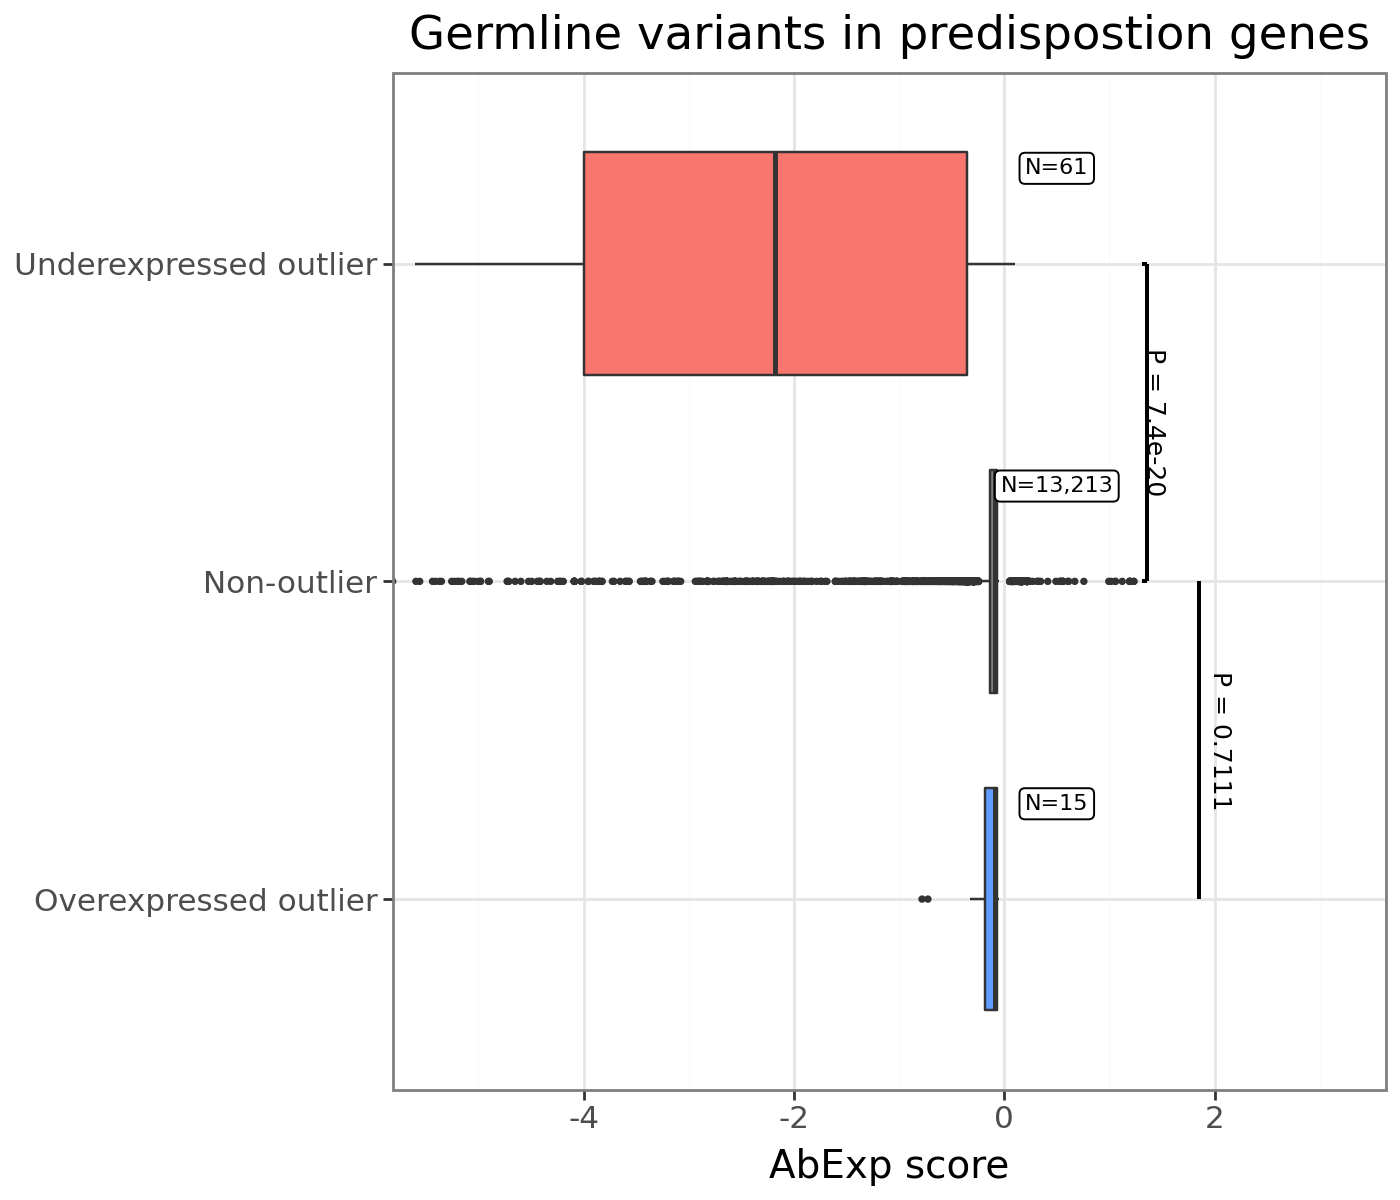

In [40]:
import pandas as pd
import numpy as np
import plotnine as pn
from scipy.stats import mannwhitneyu

tip_size = 0.05

# 1. Categorization
df_plot = predisp_snvs[abs(predisp_snvs["abexp_v1.1"]) >= 0.05].copy()
conditions = [
    (df_plot['Outlier status'] == True) & (df_plot['zScore'] < 0),
    (df_plot['Outlier status'] == False),
    (df_plot['Outlier status'] == True) & (df_plot['zScore'] > 0)
]
choices = ['Underexpressed outlier', 'Non-outlier', 'Overexpressed outlier']
df_plot['plot_group'] = np.select(conditions, choices, default='Non-outlier')

# Order: Over (Bottom/1), Non (Mid/2), Under (Top/3)
group_order = ['Overexpressed outlier', 'Non-outlier', 'Underexpressed outlier']
df_plot['plot_group'] = pd.Categorical(df_plot['plot_group'], categories=group_order, ordered=True)

# 2. Extract series for stats
under_vals = df_plot[df_plot['plot_group'] == 'Underexpressed outlier']["abexp_v1.1"]
none_vals = df_plot[df_plot['plot_group'] == 'Non-outlier']["abexp_v1.1"]
over_vals = df_plot[df_plot['plot_group'] == 'Overexpressed outlier']["abexp_v1.1"]

# 3. Stats
p_under = mannwhitneyu(under_vals, none_vals, alternative='less').pvalue if len(under_vals) > 0 else np.nan
p_over = mannwhitneyu(over_vals, none_vals, alternative='greater').pvalue if len(over_vals) > 0 else np.nan

def format_p(p):
    return f"P = {p:.1e}" if p < 0.001 else f"P = {p:.4f}"

# 4. Plot
# We define bracket positions. y_pos is the horizontal line location.
y_max = df_plot["abexp_v1.1"].max()
bracket_y = y_max * 1.1  # Position brackets slightly outside the data range

p = (
    pn.ggplot(df_plot, pn.aes(x="plot_group", y="abexp_v1.1", fill="plot_group"))
    + pn.geom_boxplot(outlier_size=0.5, width=0.7)
    + pn.coord_flip()
    + pn.scale_fill_manual(values={"Underexpressed outlier": "#f8766d", "Non-outlier": "#7f7f7f", "Overexpressed outlier": "#619cff"}, guide=None)
    + pn.theme_bw(base_size=14)
    + pn.theme(figure_size=(7, 6), axis_title_y=pn.element_blank())
    + pn.labs(y="AbExp score", title="Germline variants in predispostion genes")
    
    # --- Brackets & P-values ---
    # Bracket for Underexpressed (x=3) vs Non-outlier (x=2)
    + pn.geom_segment(pn.aes(x=2, xend=3, y=bracket_y, yend=bracket_y)) # Vertical bar (flipped)
    + pn.geom_segment(pn.aes(x=2, xend=2, y=bracket_y, yend=bracket_y - tip_size)) # Bottom tip
    + pn.geom_segment(pn.aes(x=3, xend=3, y=bracket_y, yend=bracket_y - tip_size)) # Top tip
    
    + pn.annotate("text", x=2.5, y=bracket_y * 1.05, label=format_p(p_under), size=9, angle=270)
    
    # Bracket for Overexpressed (x=1) vs Non-outlier (x=2)
    + pn.geom_segment(pn.aes(x=1, xend=2, y=bracket_y + 0.5, yend=bracket_y + 0.5)) # Vertical bar (flipped)
    + pn.annotate("text", x=1.5, y=bracket_y + 0.7, label=format_p(p_over), size=9, angle=270)
    
    # --- N Labels ---
    + pn.annotate("label", x=3.3, y=0.5, label=f"N={len(under_vals):,}", fill="white", size=8)
    + pn.annotate("label", x=2.3, y=0.5, label=f"N={len(none_vals):,}", fill="white", size=8)
    + pn.annotate("label", x=1.3, y=0.5, label=f"N={len(over_vals):,}", fill="white", size=8)
    
    # Expand the plot to make room for brackets
    + pn.scale_y_continuous(expand=(0, 0, 0.2, 0)) 
)

p

## back to code

In [55]:
smallest_columns = ["sampleID", "Variant", "germline_promoterAI", "germline_abexp_v1.1", "germline_IMPACT", "five_prime_UTR_variant_consequence", "germline_Consequence", "somatic_snv_promoterAI", "somatic_snv_abexp_v1.1", "somatic_snv_IMPACT", "somatic_snv_Consequence", "VEP_IMPACT", "VEP_Most_Severe_Consequence", "HGVSg", "HGVSc", "CharGer_Classification" , "ClinVar_Pathogenicity" , "zScore", "HUGO_Symbol", "Oncotree Code", "Oncotree Text", "ROLE_IN_CANCER", "CNV", "Tumorzellgehalt (Bioinformatik)"]

predisp_absplice["Variant"] = (
    predisp_absplice["seqnames"] + ":" + 
    predisp_absplice["POS_x"].astype(str) + ":" + 
    predisp_absplice["Ref"] + ":" + 
    predisp_absplice["Alt"]
)

predisp_snvs_underexpression = predisp_absplice[(predisp_absplice["zScore"] <= 0) & (predisp_absplice["Outlier status"] == True)]

# predisp_snvs_underexpression[smallest_columns]

predisp_snvs_underexpression[(predisp_snvs_underexpression["germline_abexp_v1.1"] <= -0.1) | 
    (predisp_snvs_underexpression["germline_promoterAI"] <= -0.1) |
    (predisp_snvs_underexpression["germline_IMPACT"].str.contains("HIGH")) ][smallest_columns]



# predisp_snvs_underexpression[ (predisp_snvs_underexpression["HUGO_Symbol"].isin(AD_inheritence["Approved symbol (HGNC)"])) & (
#     (predisp_snvs_underexpression["germline_abexp_v1.1"] <= -0.1) | 
#     (predisp_snvs_underexpression["germline_promoterAI"] <= -0.1) |
#     (predisp_snvs_underexpression["germline_IMPACT"].str.contains("HIGH")))][smallest_columns]



# final_gene_expression = predisp_snvs_underexpression[(predisp_snvs_underexpression["CharGer_Classification"] != "Pathogenic") &
#     (~predisp_snvs_underexpression["CNV"].isin(["Somatic_HDEL", "Germline_DEL"])) &
#     (
#     (predisp_snvs_underexpression["germline_abexp_v1.1"] <= -0.1) |
#     (predisp_snvs_underexpression["germline_promoterAI"] <= -0.1) |
#     (predisp_snvs_underexpression["germline_IMPACT"].str.contains("HIGH")))]

# final_gene_expression["VUS"] = "RNA_outlier"

# # final_gene_expression[~final_gene_expression["HUGO_Symbol"].isin(extended_dresden_list)][smallest_columns]
# final_gene_expression[final_gene_expression["HUGO_Symbol"].isin(AD_inheritence["Approved symbol (HGNC)"])][smallest_columns]
# final_gene_expression[smallest_columns]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [27]:
predisp_absplice[predisp_absplice["zScore"] <= 0]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [32]:
py_or_res_aberrant["geneID_short"].unique()

<ArrowStringArray>
['ENSG00000119689', 'ENSG00000196531', 'ENSG00000073584', 'ENSG00000104408',
 'ENSG00000132155', 'ENSG00000173674', 'ENSG00000051180', 'ENSG00000157764',
 'ENSG00000163930', 'ENSG00000088038',
 ...
 'ENSG00000178919', 'ENSG00000090659', 'ENSG00000135100', 'ENSG00000107807',
 'ENSG00000159184', 'ENSG00000182901', 'ENSG00000163497', 'ENSG00000183454',
 'ENSG00000123364', 'ENSG00000126752']
Length: 797, dtype: str

In [18]:
def highlight_important(col, modality="OUTRIDER"):
    # Default style is no change
    style = ['' for _ in col]
    
    # Logic for promoterAI and abexp_v1.1
    if col.name in ['promoterAI', 'abexp_v1.1']:
        style = ['background-color: #d4edda; color: #155724' if (isinstance(v, (int, float)) and v <= -0.1) else '' for v in col]
    
    # Logic for vep_impact
    elif col.name == 'vep_impact' and modality == "OUTRIDER":
        style = ['background-color: #d4edda; color: #155724' if v == 'HIGH' else '' for v in col]
    elif  col.name == 'VEP_IMPACT' and modality == "PROTRIDER":
        style = ['background-color: #d4edda; color: #155724' if (v == 'HIGH' or "missense" in v) else '' for v in col]
    elif col.name == "VEP_Most_Severe_Consequence" and modality == "PROTRIDER":
        style = ['background-color: #d4edda; color: #155724' if "missense" in v else '' for v in col]
    return style
    

# Apply the style and display
# final_gene_expression.style.apply(highlight_important, axis=0)

styled_df = predisp_snvs_underexpression[smallest_columns].style.apply(highlight_important, axis=0)
itables.show(styled_df, allow_html=True)

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [88]:
predisp_snvs_underexpression[(predisp_snvs_underexpression["CharGer_Classification"] != "Pathogenic") &
    (~predisp_snvs_underexpression["CNV"].isin(["Somatic_HDEL", "Germline_DEL"])) &
    (
    (predisp_snvs_underexpression["abexp_v1.1"] <= -0.1) |
    (predisp_snvs_underexpression["promoterAI"] <= -0.1) |
    (predisp_snvs_underexpression["VEP_IMPACT"].str.contains("HIGH")))][smallest_columns]

KeyError: 'abexp_v1.1'

In [ ]:
# 16:2096239:G:A :   synonymous_variant in NTHL1

# 5:176943853:T:G missense

#16:2096238:G:A intergenic


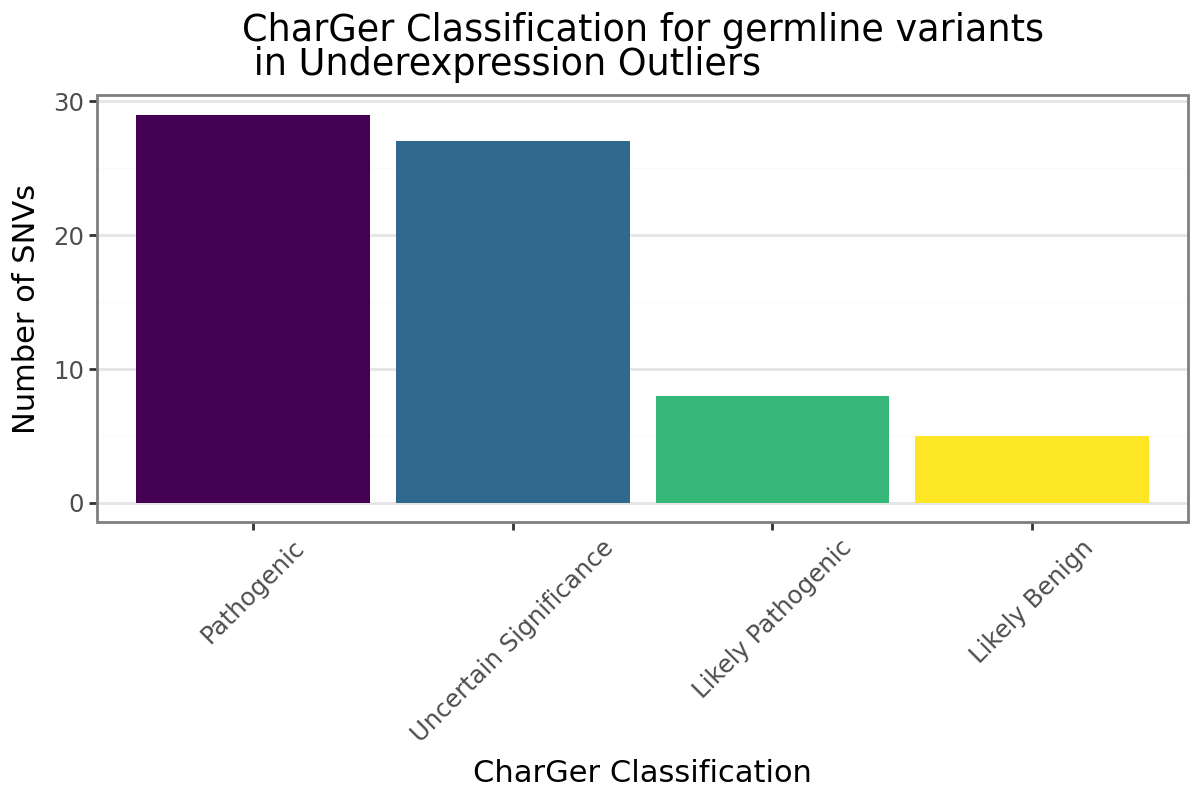

In [151]:
plot_df = predisp_snvs[
    (predisp_snvs["Outlier status"] == True) & 
    (predisp_snvs["zScore"] <= 0)
].copy()

# 2. Prepare the counts and ensure they are sorted for the bar plot
counts_df = (
    plot_df["CharGer_Classification"]
    .value_counts()
    .reset_index()
)
counts_df.columns = ["Classification", "Count"]

# Convert Classification to a categorical type with levels sorted by Count
# This ensures the bars appear in descending order
counts_df["Classification"] = pd.Categorical(
    counts_df["Classification"], 
    categories=counts_df.sort_values("Count", ascending=False)["Classification"],
    ordered=True
)

# 3. Create the Plot
p = (
    pn.ggplot(counts_df, pn.aes(x="Classification", y="Count", fill="Classification"))
    + pn.geom_col(show_legend=False)
    + pn.theme_bw()
    + pn.theme(
        figure_size=(6, 4),
        axis_text_x=pn.element_text(rotation=45), # Rotates labels
        panel_grid_major_x=pn.element_blank()
    )
    + pn.labs(
        title="CharGer Classification for germline variants\n in Underexpression Outliers",
        x="CharGer Classification",
        y="Number of SNVs"
    )
    #+ pn.scale_fill_brewer(type="qual", palette="Set3") # Nice color palette
)
p

## some other plots

/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 30397 rows containing non-finite values.


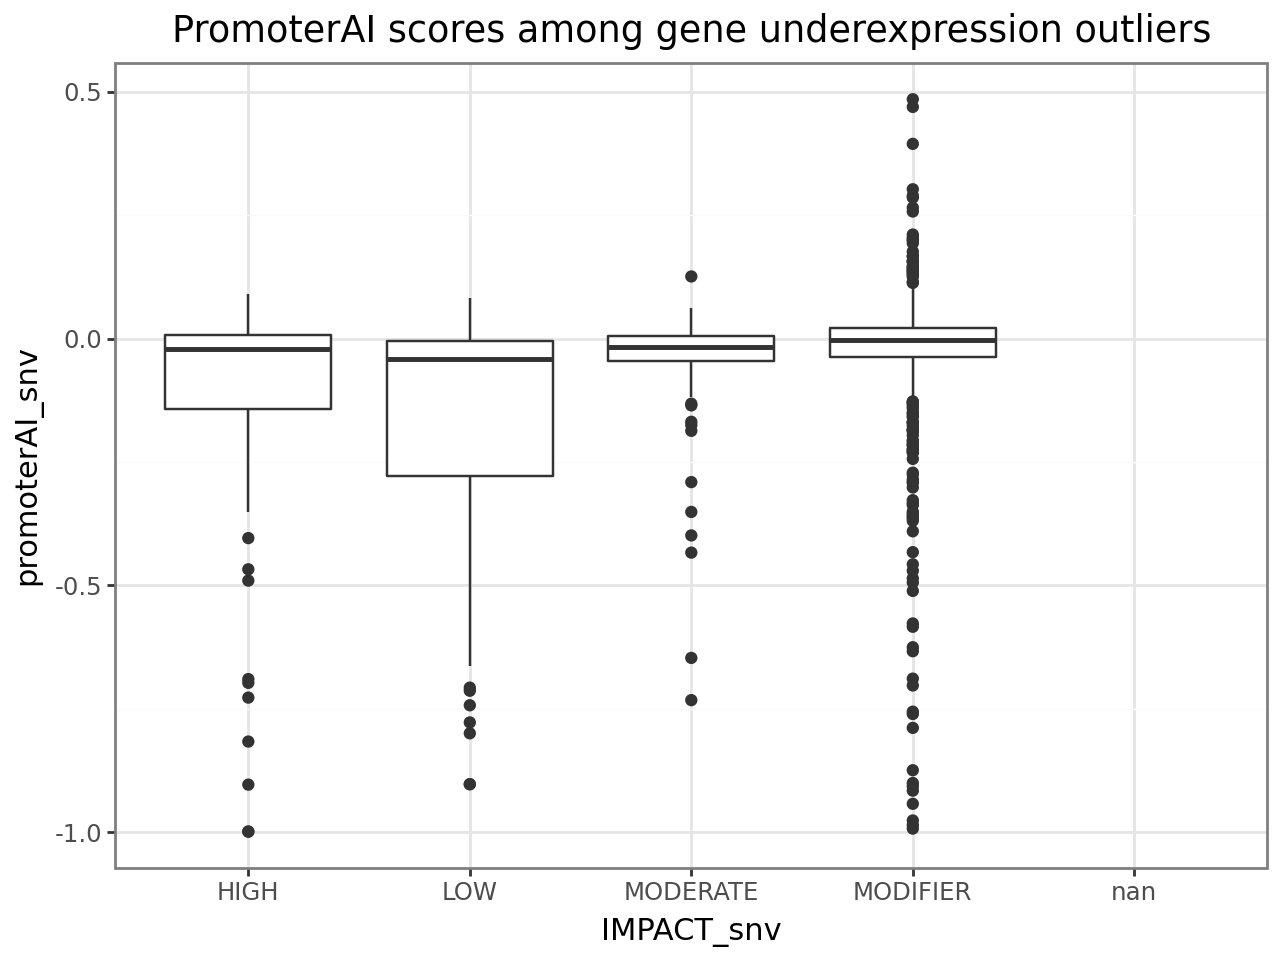

In [21]:
p1 = (pn.ggplot(py_or_res_aberrant[py_or_res_aberrant["Outlier status"] == "Underexpression"]) +
      pn.geom_boxplot(pn.aes(x="IMPACT_snv", y="promoterAI_snv")) +
      pn.labs(title="PromoterAI scores among gene underexpression outliers") +
      pn.theme_bw()
     )
p1

/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 40136 rows containing non-finite values.


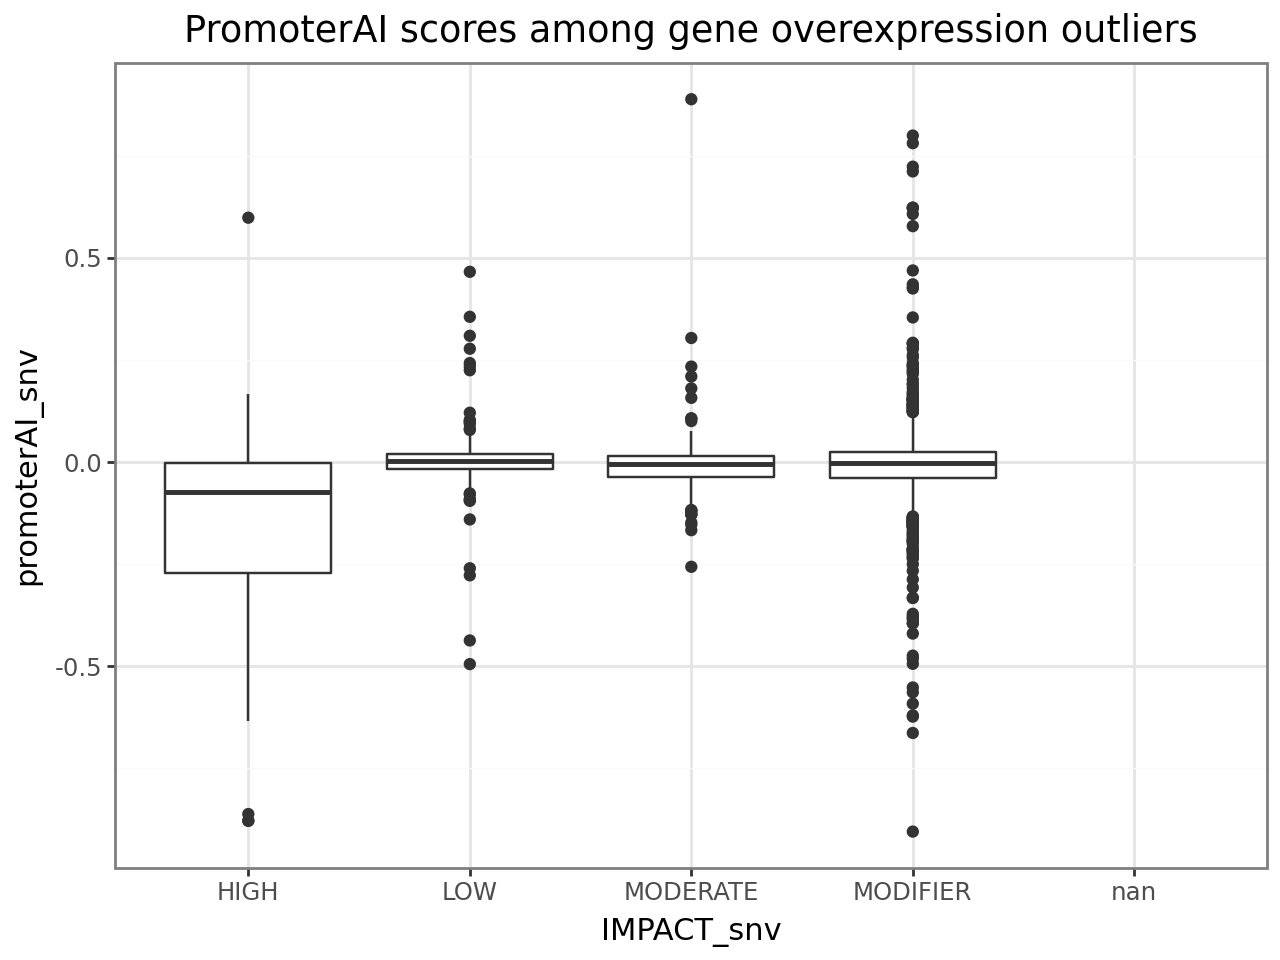

In [20]:
p1 = (pn.ggplot(py_or_res_aberrant[py_or_res_aberrant["Outlier status"] == "Overexpression"]) +
      pn.geom_boxplot(pn.aes(x="IMPACT_snv", y="promoterAI_snv")) +
      pn.labs(title="PromoterAI scores among gene overexpression outliers") +
      pn.theme_bw()
     )
p1

/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_boxplot : Removed 70533 rows containing non-finite values.


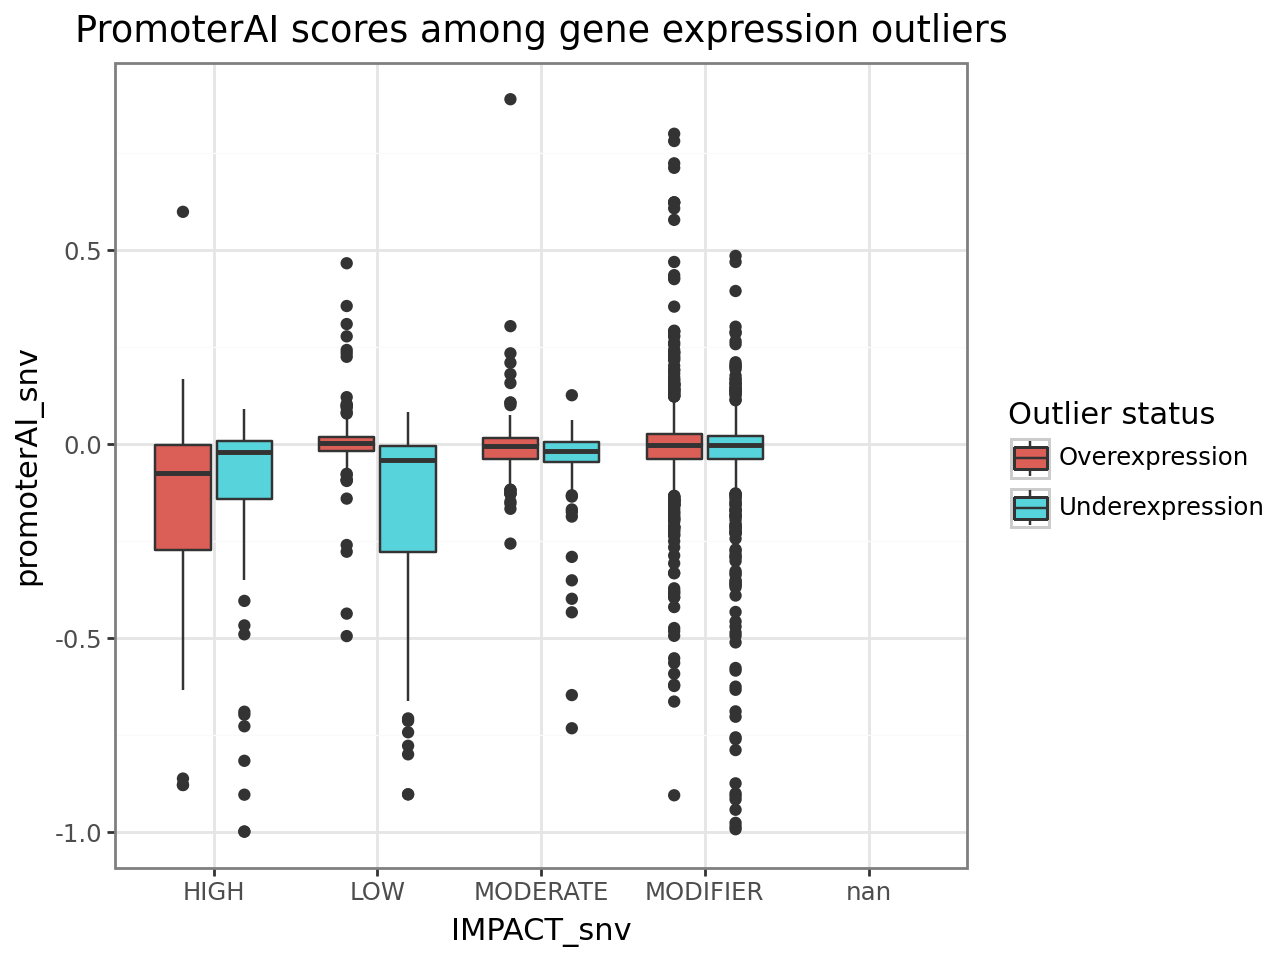

In [73]:
p1 = (pn.ggplot(py_or_res_aberrant) +
      pn.geom_boxplot(pn.aes(x="IMPACT_snv", y="promoterAI_snv", fill="Outlier status")) +
      pn.labs(title="PromoterAI scores among gene expression outliers") +
      pn.theme_bw()
     )
p1

In [27]:
interestings = py_or_res_aberrant[ (py_or_res_aberrant["promoterAI_snv"].notna()) & (py_or_res_aberrant["promoterAI_snv"] <= -0.1) &(py_or_res_aberrant["predisposition_gene"] == True) ]
interestings[["sampleID", "gene_name", "promoterAI_snv", "IMPACT_snv", "Consequence_snv", "ANNOTATION_control_snv", "ROLE_IN_CANCER", "predisposition_gene", "Oncotree Code", "Outlier status"]]

In [52]:
interestings_2 = py_or_res_aberrant[ (py_or_res_aberrant["promoterAI_snv"].notna()) & (py_or_res_aberrant["promoterAI_snv"] >= 0.1)]
interestings_2[["sampleID", "gene_name", "promoterAI_snv", "IMPACT_snv", "ANNOTATION_control_snv", "ROLE_IN_CANCER", "predisposition_gene", "Oncotree Code", "Outlier status", "Consequence_snv"]]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [46]:
py_or_res_aberrant

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


# Aberrant proteomics

In [13]:
pr_vars = merged_vars.merge(pr_res_aberrant, left_on=["sampleID", "HUGO_Symbol"],  right_on=["sampleID", "proteinID"],how="left")
pr_vars["Outlier status"] = False
pr_vars.loc[pr_vars["proteinID"].notna(), "Outlier status"] = True
pr_vars = pr_vars.merge(genes_of_interest[["geneID_short", "Inheritance cancer predisposition"]] , how="left", on="geneID_short")

In [14]:
len(pr_vars[pr_vars["zScore"] < 0][["geneID_short", "sampleID"]].drop_duplicates())

169

In [17]:
smallest_columns = ["sampleID", "Variant", "germline_promoterAI", "germline_am_pathogenicity", "five_prime_UTR_variant_consequence", "germline_abexp_v1.1", "germline_IMPACT", "germline_Consequence", "somatic_snv_promoterAI", "somatic_snv_abexp_v1.1", "somatic_snv_IMPACT", "somatic_snv_Consequence", "AlphaMissense_class", "VEP_Most_Severe_Consequence", "HGVSg", "HGVSc", "ACMG_Classification", "CharGer_Classification" , "ClinVar_Pathogenicity" , "zScore", "HUGO_Symbol", "Oncotree Code", "Oncotree Text", "IMPACT_snv", "ROLE_IN_CANCER", "CNV", "Tumorzellgehalt (Bioinformatik)"]

pr_vars["Variant"] = (
    pr_vars["seqnames_x"] + ":" + 
    pr_vars["POS"].astype(str) + ":" + 
    pr_vars["Ref"] + ":" + 
    pr_vars["Alt"]
)

pr_res_aberrant.loc[ (pr_res_aberrant["zScore"] <= 0) ]

pr_vars.loc[(pr_vars["Outlier status"] == True) & (pr_vars["zScore"] <= 0) & (pr_vars["germline_IMPACT"].notna())].value_counts(subset=["sampleID", "geneID_short"])

# pr_vars.loc[(pr_vars["Outlier status"] == True) & (pr_vars["CNV"]!="No CNV")  & (pr_vars["zScore"] <= 0) & (pr_vars["germline_IMPACT"].notna())][smallest_columns]



# pr_vars[(pr_vars["Outlier status"] == True) & (pr_vars["zScore"] <= 0)  & ((pr_vars["germline_am_pathogenicity"] >= 0.543) | (pr_vars["germline_abexp_v1.1"] <= -0.1) | 
#                                                                            (pr_vars["germline_IMPACT"].str.contains("HIGH")) | (pr_vars["germline_Consequence"] == "missense") | 
#                                                                            (pr_vars["germline_promoterAI"] <= -0.1) | ((pr_vars["five_prime_UTR_variant_consequence"] != "-") & (pr_vars["five_prime_UTR_variant_consequence"].notna())))][smallest_columns]


# pr_vars[(pr_vars["Outlier status"] == True) & (pr_vars["zScore"] <= 0) & (pr_vars["Inheritance cancer predisposition"].str.contains("AD"))  & ((pr_vars["germline_am_pathogenicity"] >= 0.543) | (pr_vars["germline_abexp_v1.1"] <= -0.1) | 
#                                                                            (pr_vars["germline_IMPACT"].str.contains("HIGH")) | (pr_vars["germline_Consequence"] == "missense") | 
#                                                                            (pr_vars["germline_promoterAI"] <= -0.1) | ((pr_vars["five_prime_UTR_variant_consequence"] != "-") & (pr_vars["five_prime_UTR_variant_consequence"].notna())))][smallest_columns]

# pr_vars[(pr_vars["Outlier status"] == True) & (pr_vars["zScore"] <= 0) & (pr_vars["CharGer_Classification"] != "Pathogenic") & (pr_vars["Inheritance cancer predisposition"].str.contains("AD"))  & ((pr_vars["germline_am_pathogenicity"] >= 0.543) | (pr_vars["germline_abexp_v1.1"] <= -0.1) | 
#                                                                            (pr_vars["germline_IMPACT"].str.contains("HIGH")) | (pr_vars["germline_Consequence"] == "missense") | 
#                                                                            (pr_vars["germline_promoterAI"] <= -0.1) | ((pr_vars["five_prime_UTR_variant_consequence"] != "-") & (pr_vars["five_prime_UTR_variant_consequence"].notna())))][smallest_columns]

# final_pr_vus = pr_vars[(pr_vars["CharGer_Classification"] != "Pathogenic") & (pr_vars["Outlier status"] == True) & (pr_vars["zScore"] <= 0)  & 
#                         ((pr_vars["germline_am_pathogenicity"] >= 0.543) | (pr_vars["germline_abexp_v1.1"] <= -0.1) | (pr_vars["germline_IMPACT"].str.contains("HIGH")) | (pr_vars["germline_Consequence"].str.contains("missense")) |  
#                         (pr_vars["germline_promoterAI"] <= -0.1) | ((pr_vars["five_prime_UTR_variant_consequence"] != "-") & (pr_vars["five_prime_UTR_variant_consequence"].notna())))]
# final_pr_vus["VUS"] = "Protein_outlier"


# styled_df_pr = final_pr_vus[smallest_columns].style.apply(highlight_important, modality="PROTRIDER", axis=0)
# itables.show(styled_df_pr, allow_html=True)

pr_vars[(pr_vars["Outlier status"] == True) & (pr_vars["zScore"] <= 0)  & ((pr_vars["germline_abexp_v1.1"] <= -0.1) | (pr_vars["germline_am_pathogenicity"] > 0.543) |  (pr_vars["germline_IMPACT"].str.contains("HIGH")) | (pr_vars["germline_Consequence"].str.contains("missense")) |  (pr_vars["VEP_Most_Severe_Consequence"].str.contains("missense")) | (pr_vars["germline_promoterAI"] <= -0.1))][smallest_columns]



pr_vars[(pr_vars["Outlier status"] == True) & (pr_vars["Inheritance cancer predisposition"].str.contains("AD")) & (pr_vars["zScore"] <= 0)  & ((pr_vars["germline_abexp_v1.1"] <= -0.1) | (pr_vars["germline_IMPACT"].str.contains("HIGH")) | (pr_vars["germline_Consequence"].str.contains("missense")) |  (pr_vars["VEP_Most_Severe_Consequence"].str.contains("missense")) | (pr_vars["germline_promoterAI"] <= -0.1))][smallest_columns]

# final_pr_vus[smallest_columns]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [47]:
pr_vars[pr_vars["zScore"] < 0][smallest_columns]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [ ]:
pr_vars[(pr_vars["CharGer_Classification"] != "Pathogenic") & (pr_vars["Outlier status"] == True) & (pr_vars["zScore"] <= 0)  & 
    ((pr_vars["abexp_v1.1"] <= -0.1) | (pr_vars["VEP_IMPACT"].str.contains("HIGH")) | 
     (pr_vars["VEP_Most_Severe_Consequence"].str.contains("missense")) | (pr_vars["promoterAI"] <= -0.1)) & 
    (~pr_vars["CNV"].str.contains("DEL"))][smallest_columns]



pr_vars[(pr_vars["Outlier status"] == True) & (pr_vars["zScore"] >= 0)  & ((pr_vars["abexp_v1.1"] >= 0.1) |  (pr_vars["vep_consequence"].str.contains("missense")) | (pr_vars["promoterAI"] >= 0.1))][smallest_columns]


In [84]:
or_res_path = "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/all_cohorts/oht_cov_diag_lr_0_0001_epoc200_gpu/or_variants_predisppadjust_cnv.parquet"
needed_cols = ["sampleID", "zScore", "pValue", "padjust", "IMPACT", "geneID",  "geneID_short",
               "#Uploaded_variation_snv", "IMPACT_snv", "ANNOTATION_control_snv", "Consequence_snv",
               "Location_indel", "IMPACT_indel", "ANNOTATION_control_indel", "Consequence_indel", "promoterAI_snv",
               "padjust_predisp", "padjust_predisp_extended", "CNV" ]
py_or_res_pr = pl.scan_parquet(or_res_path).select(needed_cols).filter((pl.col("geneID_short").is_in(final_pr_vus["geneID_short_x"]))).collect().to_pandas()

# py_or_res_all = py_or_res_all[(py_or_res_all["padjust_predisp_extended"] <= 0.05) | (py_or_res_all["padjust"] <= 0.05)]


/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/envs/protrider_env/lib/python3.13/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


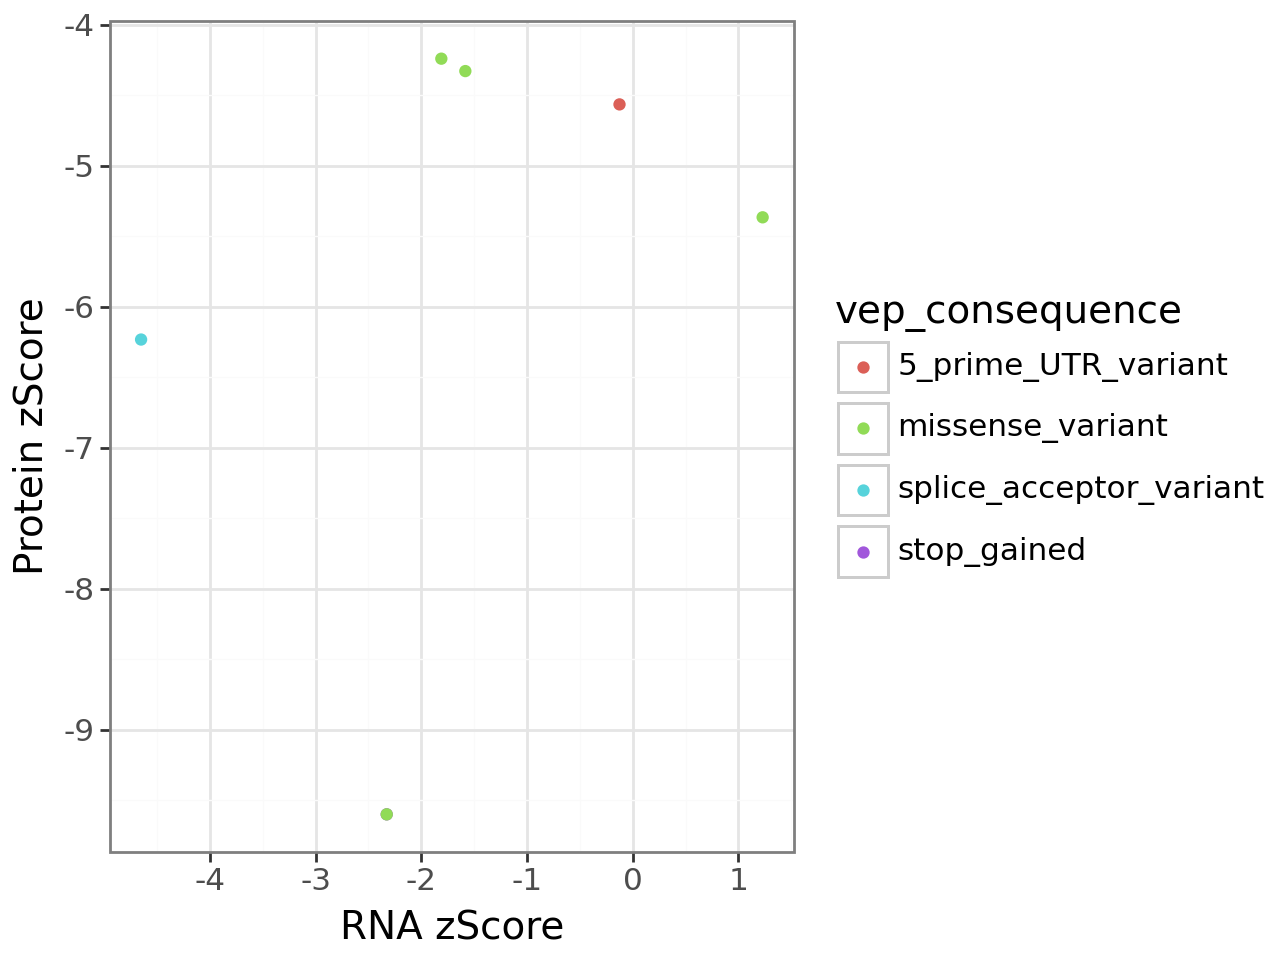

In [85]:
to_plot = final_pr_vus.rename(columns={"zScore": "Protein zScore"}).merge(py_or_res_pr.rename(columns={"zScore": "RNA zScore"}), how="left", left_on=["sampleID", "geneID_short_x"], right_on=["sampleID", "geneID_short"])
pn.ggplot(to_plot) + pn.geom_point(pn.aes(x="RNA zScore", y="Protein zScore", color="vep_consequence")) + pn.theme_bw(base_size=14)



In [86]:
to_plot[["RNA zScore" , "proteinID"]]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [74]:
interestings = pr_res_aberrant[ (pr_res_aberrant["promoterAI_snv"].notna()) & (pr_res_aberrant["promoterAI_snv"] <= -0.1) &(pr_res_aberrant["predisposition_gene"] == True) ]
interestings[["sampleID", "proteinID", "promoterAI_snv", "IMPACT_snv", "Consequence_snv", "ANNOTATION_control_snv", "ROLE_IN_CANCER", "predisposition_gene", "Oncotree Code", "Outlier status"]]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [75]:
interestings = pr_res_aberrant[ (pr_res_aberrant["promoterAI_snv"].notna()) & (pr_res_aberrant["promoterAI_snv"] >= 0.1) &(pr_res_aberrant["predisposition_gene"] == True) ]
interestings[["sampleID", "proteinID", "promoterAI_snv", "IMPACT_snv", "Consequence_snv", "ANNOTATION_control_snv", "ROLE_IN_CANCER", "predisposition_gene", "Oncotree Code", "Outlier status"]]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [ ]:
interestings_2 = pr_res_aberrant[ (pr_res_aberrant["promoterAI_snv"].notna()) & (pr_res_aberrant["promoterAI_snv"] >= 0.1)]
interestings_2[["sampleID", "proteinID", "promoterAI_snv", "IMPACT_snv", "ANNOTATION_control_snv", "ROLE_IN_CANCER", "predisposition_gene", "Oncotree Code", "Outlier status", "Consequence_snv"]]

In [82]:
interestings_2 = pr_res_aberrant[ (pr_res_aberrant["promoterAI_snv"].notna()) & (pr_res_aberrant["promoterAI_snv"] <= -0.1) &  (pr_res_aberrant["Outlier status"] == "Underexpression")]
interestings_2[["sampleID", "proteinID", "promoterAI_snv", "IMPACT_snv", "ANNOTATION_control_snv", "ROLE_IN_CANCER", "predisposition_gene", "Oncotree Code", "Outlier status", "Consequence_snv"]]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


# splicing outliers

In [15]:
splicing_res_outliers = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_splicing/results/v19/fraser/aggregated_outliers_variants.tsv", sep="\t")
splicing_res_outliers = pd.merge(splicing_res_outliers, sa, left_on="sampleID", right_on="pid")


In [16]:
splicing_res_outliers = pd.merge(splicing_res_outliers, dresden_dt_cgc[["gene_name", "gene_type", "geneID", "ROLE_IN_CANCER", "predisposition_gene"]], on="geneID", how="left")


In [40]:
print(splicing_res_outliers[~splicing_res_outliers["promoterAI_snv"].notna()].shape)
splicing_res_outliers[splicing_res_outliers["promoterAI_snv"].notna()]["IMPACT_snv"].value_counts()


(398784, 95)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [24]:
interestings = splicing_res_outliers[ (splicing_res_outliers["promoterAI_snv"].notna()) & (splicing_res_outliers["promoterAI_snv"] <= -0.1) &(splicing_res_outliers["predisposition_gene"] == True) ]
interestings[["sampleID", "hgncSymbol", "promoterAI_snv", "IMPACT_snv", "Consequence_snv", "ANNOTATION_control_snv", "ROLE_IN_CANCER", "predisposition_gene", "Oncotree Code"]]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [25]:
interestings = splicing_res_outliers[ (splicing_res_outliers["promoterAI_snv"].notna()) & (splicing_res_outliers["promoterAI_snv"] >= 0.1) &(splicing_res_outliers["predisposition_gene"] == True) ]
interestings[["sampleID", "hgncSymbol", "promoterAI_snv", "IMPACT_snv", "Consequence_snv", "ANNOTATION_control_snv", "ROLE_IN_CANCER", "predisposition_gene", "Oncotree Code"]]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [28]:
interestings = splicing_res_outliers[ (splicing_res_outliers["promoterAI_snv"].notna()) & (splicing_res_outliers["promoterAI_snv"] <= -0.1) ]
interestings[["sampleID", "hgncSymbol", "promoterAI_snv", "IMPACT_snv", "Consequence_snv", "ANNOTATION_control_snv", "ROLE_IN_CANCER", "predisposition_gene", "Oncotree Code"]]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [29]:
interestings = splicing_res_outliers[ (splicing_res_outliers["promoterAI_snv"].notna()) & (splicing_res_outliers["promoterAI_snv"] >= 0.1) ]
interestings[["sampleID", "hgncSymbol", "promoterAI_snv", "IMPACT_snv", "Consequence_snv", "ANNOTATION_control_snv", "ROLE_IN_CANCER", "predisposition_gene", "Oncotree Code"]]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)
